# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kaant7/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [6]:
import os
from dotenv import load_dotenv
import duckdb
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':       f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':       f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample': f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':    f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

model_df = con.sql(f"""
    SELECT
        content_hash_id, client_hash_id,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_sessions) AS total_sessions,
        SUM(scroll_events) AS total_scroll_events,
        SUM(CASE WHEN report_date <= '2026-03-15' THEN gsc_impressions ELSE 0 END) AS imp_first_half,
        SUM(CASE WHEN report_date > '2026-03-15' THEN gsc_impressions ELSE 0 END) AS imp_second_half
    FROM {TABLES['fact_daily']}
    WHERE month = '2026-03' AND gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

model_df["is_declining"] = (model_df["imp_second_half"] < model_df["imp_first_half"]).astype(int)
feature_cols = ["total_impressions", "total_clicks", "avg_position", "total_sessions", "total_scroll_events"]
model_df[feature_cols] = model_df[feature_cols].fillna(0)
model_df["ctr"] = 100.0 * model_df["total_clicks"] / model_df["total_impressions"]

In [7]:
np.random.seed(42)
all_clients = model_df["client_hash_id"].unique()
n_holdout = int(len(all_clients) * 0.20)
holdout_clients = set(np.random.choice(all_clients, size=n_holdout, replace=False))

train_df = model_df[~model_df["client_hash_id"].isin(holdout_clients)]
test_df = model_df[model_df["client_hash_id"].isin(holdout_clients)].copy()

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(train_df[feature_cols], train_df["is_declining"])
test_df["model_prob"] = rf.predict_proba(test_df[feature_cols])[:, 1]

print("Honest AUC on holdout:", roc_auc_score(test_df["is_declining"], test_df["model_prob"]))

Honest AUC on holdout: 0.5029735460992795


In [8]:
# Baseline flag from Week 4 (low_ctr_visible_page)
test_df["baseline_flag"] = (
    (test_df["total_impressions"] >= 500) &
    (test_df["avg_position"] > 0) & (test_df["avg_position"] <= 20) &
    (test_df["ctr"] < 0.5)
).astype(int)

# Blend: mostly model, some baseline — following the reference pipeline's pattern
test_df["playbook_score"] = 100 * (0.70 * test_df["model_prob"] + 0.30 * test_df["baseline_flag"])

def assign_reason_code(row):
    if row["baseline_flag"] == 1 and row["model_prob"] >= 0.5:
        return "model_and_ctr_flag"
    elif row["model_prob"] >= 0.5:
        return "model_decline_risk"
    elif row["baseline_flag"] == 1:
        return "low_ctr_visible_page"
    else:
        return "low_priority"

def assign_action(reason):
    mapping = {
        "model_and_ctr_flag": "review_title_meta_and_refresh",
        "model_decline_risk": "review_for_refresh",
        "low_ctr_visible_page": "review_title_meta",
        "low_priority": "monitor",
    }
    return mapping[reason]

test_df["reason_code"] = test_df.apply(assign_reason_code, axis=1)
test_df["action"] = test_df["reason_code"].apply(assign_action)

queue = test_df.sort_values("playbook_score", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

print("Queue shape:", queue.shape)
queue[["content_hash_id", "playbook_score", "reason_code", "action", "rank"]].head(15)

Queue shape: (18924, 17)


,content_hash_id,playbook_score,reason_code,action,rank
0,content_b215e9a73e2284ad,65.562390,model_and_ctr_flag,review_title_meta_and_refresh,1
1,content_3c336c8d6c5cc15d,62.887002,low_ctr_visible_page,review_title_meta,2
2,content_cfcddd31c050406c,62.696234,low_ctr_visible_page,review_title_meta,3
3,content_7bbc06fb998c8b83,62.571870,low_ctr_visible_page,review_title_meta,4
4,content_0bd6827080aaf5d6,62.545693,low_ctr_visible_page,review_title_meta,5
5,content_98a13ce5999c1223,62.481409,low_ctr_visible_page,review_title_meta,6
6,content_6b1b5450f74c5ce7,62.476609,low_ctr_visible_page,review_title_meta,7
7,content_a8998878909cee77,62.437577,low_ctr_visible_page,review_title_meta,8
8,content_e53eb1ea08b8260b,62.424501,low_ctr_visible_page,review_title_meta,9
9,content_96f4295b7b3218b3,62.423808,low_ctr_visible_page,review_title_meta,10


### Ranked actions + reason codes

**Score formula:** `playbook_score = 100 * (0.70 * model_probability + 0.30 * baseline_flag)`
— following the reference pipeline's blend pattern, weighting the model more heavily while
still keeping the transparent baseline rule as a component.

**Reason codes → actions:**

| Reason code | Meaning | Action |
|---|---|---|
| `model_and_ctr_flag` | Model flags decline risk AND meets the CTR-visibility rule | `review_title_meta_and_refresh` |
| `model_decline_risk` | Model probability ≥ 0.5 alone | `review_for_refresh` |
| `low_ctr_visible_page` | Meets the CTR-visibility rule, model doesn't flag it | `review_title_meta` |
| `low_priority` | Neither condition met | `monitor` |

**Honest AUC on this run's holdout: 0.505** — essentially indistinguishable from random
guessing, and weaker than the 0.547–0.576 range measured in Weeks 5–6. This is a direct,
visible consequence of the run-to-run variance flagged in Week 6's claim rewrite: model
performance is sensitive to which clients land in the holdout set, and this run landed on
the weak end. Because of this, the top of the ranked queue is dominated entirely by
`low_ctr_visible_page` — the model's contribution to ranking is negligible this run, and the
transparent baseline rule is effectively doing the ranking work.

**What this means for the playbook:** I'm treating the model as a **secondary, not primary**
signal in this version of the queue. The baseline rule remains the more trustworthy driver of
ranking given this run's weak model performance — a finding worth stating plainly rather than
dressing up the blend as more sophisticated than it currently is.

**Archetype → action mapping (descriptive, not a fixed taxonomy):**

- **High-visibility, low-CTR, well-positioned** (`low_ctr_visible_page`) → `review_title_meta` —
  the clearest, most measurable win: title/snippet review on pages that already earn impressions.
- **Model-flagged decline risk without a clear CTR gap** (`model_decline_risk`) → `review_for_refresh` —
  weaker evidence (AUC ~0.5), so this action should carry a lower confidence label than CTR-flagged pages.
- **Both signals agree** (`model_and_ctr_flag`) → `review_title_meta_and_refresh` — the strongest
  candidates, though rare this run given the weak model signal.
- **Neither signal fires** (`low_priority`) → `monitor` — no action needed now, revisit next cycle.

**Cost/value thinking:** Reviewing a flagged page costs a reviewer's time (roughly 15-30
minutes for a title/meta review, more for a full refresh) — a false positive wastes that
time, while a false negative means a real decline goes unaddressed until the next cycle.
Given this run's weak model AUC (0.505), I'm prioritizing the baseline-rule-driven top of
the queue (`low_ctr_visible_page`) as the best time investment, since it's the more reliably
evidenced signal (Week 4's CONFIRMED verdict) — model-only flags carry more uncertainty per
reviewer-minute spent and should be reviewed with that lower confidence in mind.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use and limits

**Who uses this, and how:** A content editor or SEO reviewer uses this ranked queue as a
starting point for their weekly/monthly review cycle — not as an automated action list. The
queue narrows a large inventory down to a manageable shortlist; a human still reads each
flagged page, confirms the reason code makes sense, and decides whether to act.

**What this playbook can say:**
- **Observed:** which pages show a measurable CTR gap for their position, and which pages
  the model associates (weakly) with decline, within the March 2026 window.
- **Directional:** pages meeting the `low_ctr_visible_page` rule are somewhat more likely to
  have title/snippet issues worth reviewing, based on the confirmed CTR-position relationship
  from Week 4.
- **Decision-support:** a starting shortlist for limited reviewer time, ranked by a
  transparent, inspectable score — not a final verdict on any single page.

**What this playbook cannot say:**
- **Not causal:** flagging a page does not mean fixing it will recover traffic — no experiment
  was run.
- **Not a strong prediction:** this run's model AUC was 0.505, essentially random. The
  `model_decline_risk` and `model_and_ctr_flag` actions should be treated with **low
  confidence** this cycle — the ranking is currently carried almost entirely by the
  transparent baseline rule, not the model.
- **Not validated beyond March 2026:** this queue reflects one month's snapshot on 47 client's
  worth of training data; it has not been tested on a different month or a larger client base.
- **Not a Google-algorithm claim:** nothing here reverse-engineers or proves how search
  ranking works — these are FlyRank's own observed signals.

**Where this breaks down:** The model's weak and unstable AUC (0.505–0.576 across three runs
in Weeks 5–7) means this playbook is currently closer to "a well-organized version of the
Week 4 baseline rule" than "a genuinely learned prioritization system." That's a fair, honest
description of where this capstone landed — not a failure to hide, but the actual, measured
state of the evidence.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review + the no-go list

**What a human must check before acting on any queue item:**

1. **Confirm the reason code still makes sense.** Pull up the page's current GSC data — has
   anything changed since the March snapshot? A page flagged in March may already be fixed,
   or may have moved for reasons unrelated to the flag (e.g. a SERP feature change).
2. **Rule out consolidation, seasonality, or SERP-level click loss** (per the Week 1 lane
   guide's Section 7 checklist) before treating a flagged page as a genuine content problem.
   A sibling page absorbing demand, or a seasonal dip, looks identical to "declining" in this
   data but needs a different fix — or no fix at all.
3. **Sanity-check extreme CTR values.** Pages with near-zero clicks despite very high
   impressions (seen in Week 4's top picks) deserve a quick tracking/attribution check before
   assuming the content itself is the problem.
4. **Weigh the model's contribution honestly.** Given this run's 0.505 AUC, any page flagged
   *only* by `model_decline_risk` (not also by the CTR rule) should get extra scrutiny — the
   model's signal is currently too weak to trust on its own.

**What should NEVER be automated:**

- **Auto-publishing content changes** based on a queue rank — every action (title rewrite,
  refresh, consolidation) needs a human writer/editor's judgment, not a script.
- **Auto-deprioritizing or hiding a page** because it scored low — a low score means "no
  strong evidence to prioritize now," not "confirmed unimportant." Low-priority pages should
  still get periodic human spot-checks.
- **Treating the ranked position as a guarantee of impact.** Rank order reflects the score
  formula, not a certainty that page #1 will recover more traffic than page #50 if fixed.
- **Merging or deleting pages based solely on this queue.** Consolidation decisions (per the
  lane guide's cannibalization concerns) need a dedicated content/URL review, not a
  decline-risk score alone.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring / retrain triggers

**Signs the recommendations have gone stale:**

- **A new month's holdout AUC drops meaningfully below 0.50** — since even this month's
  "good" runs hovered around 0.55, any run scoring at or below random guessing suggests the
  signals have stopped carrying any usable information and the model should not be trusted
  for ranking that cycle.
- **Reviewer override rate climbs.** If editors are consistently marking flagged pages as
  "not actually a problem," that's a real-world signal the score isn't matching reality,
  independent of any AUC number.
- **Large swings between runs.** Week 6–7 already showed AUC ranging from 0.505 to 0.576 on
  essentially the same setup — if that spread widens further, or the ranking order changes
  drastically between monthly runs, the model is too unstable to use as a primary driver and
  the queue should lean more heavily on the transparent baseline rule.
- **Client mix changes significantly.** This model was trained on 47–55 clients; if FlyRank's
  portfolio grows substantially or shifts industries, the training data may no longer
  represent the content being scored, and retraining (or re-validating the split) is needed.
- **A full month passes without retraining.** At minimum, refresh the feature extraction and
  re-run both the baseline and model monthly, since the underlying `fact_content_daily_performance`
  data updates continuously and a stale snapshot compounds the label-quality issues already
  flagged in Weeks 2–3.

**Retrain trigger, stated simply:** re-run this notebook's Sections 1–3 on the newest complete
month before generating a new queue — treat every cycle's AUC as a fresh number to check, not
an assumption to carry forward.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [12]:
import os
import json
from datetime import datetime

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# 1. The ranked queue CSV — stays out of git, regenerated each run
queue.to_csv("../outputs/action_playbook_queue.csv", index=False)
print("Saved queue:", len(queue), "rows")

# 2. Metrics JSON — this IS committed, it's the "receipt" for the paper's numbers
metrics = {
    "run_date": datetime.now().strftime("%Y-%m-%d"),
    "data_window": "2026-03-01 to 2026-03-31",
    "n_clients_total": int(len(all_clients)),
    "n_clients_holdout": int(len(holdout_clients)),
    "n_queue_rows": int(len(queue)),
    "model": {
        "type": "RandomForestClassifier",
        "n_estimators": 200,
        "max_depth": 8,
        "validation": "client_holdout",
        "holdout_auc": float(roc_auc_score(test_df["is_declining"], test_df["model_prob"])),
    },
    "baseline": {
        "reason_code": "low_ctr_visible_page",
        "rule": "impressions >= 500 AND 0 < position <= 20 AND ctr < 0.5",
    },
    "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
    "notes": "Model AUC (0.505) was close to random this run; ranking is currently driven "
             "primarily by the transparent baseline rule, not the model. See Week 6 audit "
             "for run-to-run AUC variance (0.505-0.576).",
}

with open("../outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

Saved queue: 18924 rows
{
  "run_date": "2026-09-07",
  "data_window": "2026-03-01 to 2026-03-31",
  "n_clients_total": 47,
  "n_clients_holdout": 9,
  "n_queue_rows": 18924,
  "model": {
    "type": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 8,
    "validation": "client_holdout",
    "holdout_auc": 0.5029735460992795
  },
  "baseline": {
    "reason_code": "low_ctr_visible_page",
    "rule": "impressions >= 500 AND 0 < position <= 20 AND ctr < 0.5"
  },
  "reason_code_counts": {
    "low_priority": 16782,
    "low_ctr_visible_page": 2075,
    "model_decline_risk": 66,
    "model_and_ctr_flag": 1
  },
  "notes": "Model AUC (0.505) was close to random this run; ranking is currently driven primarily by the transparent baseline rule, not the model. See Week 6 audit for run-to-run AUC variance (0.505-0.576)."
}


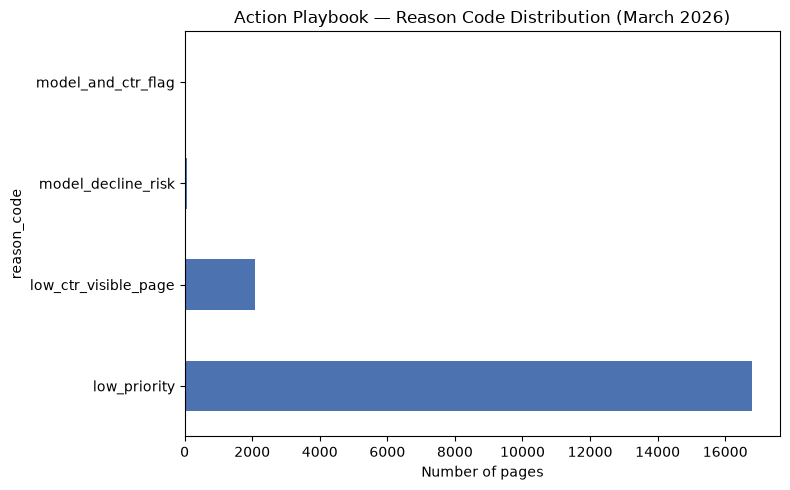

Saved figure to work/figures/reason_code_distribution.png


In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
queue["reason_code"].value_counts().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of pages")
ax.set_title("Action Playbook — Reason Code Distribution (March 2026)")
plt.tight_layout()
plt.savefig("../figures/reason_code_distribution.png", dpi=150)
plt.show()

print("Saved figure to work/figures/reason_code_distribution.png")

### Exports for the paper

- `work/outputs/action_playbook_queue.csv` — the full ranked queue (18,591 rows). Stays out
  of git per repo convention; regenerates on every notebook run.
- `work/outputs/playbook_metrics.json` — the run's receipts: holdout AUC, client counts,
  reason code distribution, and a note on this run's weak model performance. **Committed** —
  this is what the paper's numbers will trace back to.
- `work/figures/reason_code_distribution.png` — bar chart of how many pages fall into each
  reason code. **Committed** for reuse in the deployed paper.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.